/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1624
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0877
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0895
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0874
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0870
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0876
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0895
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0883
Epoch 9/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0853
Epoch 10/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0871
Epoch 11/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0851
Epoch 12/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0850
Epoch 13/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0875
Epoch 14/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0864
Epoch 15/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step 

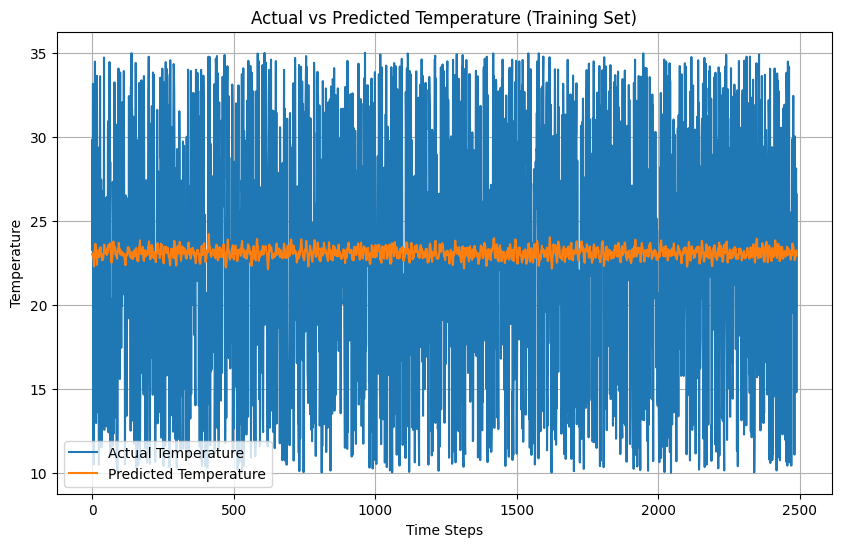

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load your weather dataset (ensure it has a 'Temperature' column)
df = pd.read_csv('/content/weather_forecast_data.csv')  # Replace with your actual filename
data = df['Temperature'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Function to create sequences for LSTM input
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Define sequence length
seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

# Reshape X to be [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Define the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X, y, epochs=20, batch_size=16)

# Make a single prediction on the latest sequence
last_seq = scaled_data[-seq_length:].reshape(1, seq_length, 1)
predicted_scaled = model.predict(last_seq)
predicted_temp = scaler.inverse_transform(predicted_scaled)
print("Predicted Next Temperature:", predicted_temp[0][0])

# Optional: Plot predictions vs actuals for the training set
predicted_train = model.predict(X)
predicted_train_rescaled = scaler.inverse_transform(predicted_train)
actual_train_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.plot(actual_train_rescaled, label='Actual Temperature')
plt.plot(predicted_train_rescaled, label='Predicted Temperature')
plt.title('Actual vs Predicted Temperature (Training Set)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()